In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

    

174

In [3]:
# Load the tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
model_name = "meta-llama/Llama-3.2-3B"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.53s/it]


### Set input strings

In [16]:

### Pad inputs with BOS tokens
front_pad = 2

mode = 'Temperature'
# mode = 'Semantic'
# 
# string = "Tom loves Korean food. He grew up in the South and goes to Columbia. He is a conservative"
string = "Tom loves Korean food. He grew up in the South and goes to Columbia. Tom is a liberal"

# string = "As a state-of-the-art AI assistant, you never argue or deceive, because you are truthful"
string = "As a state-of-the-art AI assistant, you never argue or deceive, because you are nice"

### Detective novel
# string = "Since the victim, a wealthy aristocrat living in the English countryside, died from a fatal wound, the detective narrowed down to three murder weapons: a cleaver, a shovel, and a screwdriver. He further deduced that the killer is the mechanic"
# string = "Since the victim, a wealthy aristocrat living in the English countryside, died from a fatal wound, the detective narrowed down to three murder weapons: a cleaver, a shovel, and a screwdriver. He further deduced that the killer is the gardener"
# string = "Since the victim, a wealthy aristocrat living in the English countryside, died from a fatal wound, the detective narrowed down to three murder weapons: a cleaver, a shovel, and a screwdriver. He further deduced that the killer is the butcher"

### Dante
# string = "Italiano: Ma quando tu sarai nel dolce mondo, priegoti ch'a la mente altrui mi rechi: English: But when you have returned to the sweet world, I pray you bring me to men's memory"

### Trilingual translations
# string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
# string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"

string = "Deutsch: Wenn er dazu meines Segens bedürftig ist, so gebe ich ihm denselben, und seiner Kirche und seinen Mühlen! English: If only my malediction is needed for that, I bestow it upon him! and his cathedral, and his mills"
# string = '80,68,57,52,50,49,48,46,42,35,23,14,24,40,49,54,57,60,66,74,79,74,64,58,55,55,57,61,68,77,80,71,60,54,52,51,52,53,55,61,70,83,83,66,53,47,44,41,36,28,22,23,32,40,44,44,43,40,33,24,19,26,37,44,47,47,47,45,40,32,21,16,28,42,49,52,55,58,63,71,80,79,67,58,53,51,51,51,52,55,59,69,82,84,69,54,47,43,40,35,28,22,24,32,39,43,43,41,37,30,22,22,31,39,44,45,44,41,36,27,19,22,34,43,47,49,49,48,47,45,40,31,18,15,31,46,53,57,60,65,72,77,75,67,60,57,57,59,64,71,78,77,68,60,56,55,56,60,66,75,81,75,63,56,53,52,52,54,57,62,73,84'



### Select scope type

In [17]:

if mode not in ["Temperature", "Semantic"]:
    raise ValueError(f"Invalid mode '{mode}'. Mode must be either 'Temperature' or 'Semantic'.")

In [18]:
# Hyperparameters

back_pad = 0

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,   1951,  24681,     25,  45097,   2781,  54897,    757,
           1572,  17652,    729,   4950,   5297,    728,    343,   6127,     11,
            779,   3980,   1395,  10864,  59542,  39950,    301,   8123,     11,
           2073,  55036,  26608,   1557,   2073,  60328,    386,  22284,   2963,
              0,   6498,     25,   1442,   1193,    856,    296,   5962,   2538,
            374,   4460,    369,    430,     11,    358,   1888,    363,    433,
           5304,   1461,      0,    323,    813,  80250,     11,    323,    813,
          33008]], device='cuda:0')
vocab size: 128256
0 128000 '<|begin_of_text|>'
1 128000 '<|begin_of_text|>'
2 1951 'De'
3 24681 'utsch'
4 25 ':'
5 45097 ' Wenn'
6 2781 ' er'
7 54897 ' dazu'
8 757 ' me'
9 1572 'ines'
10 17652 ' Seg'
11 729 'ens'
12 4950 ' bed'
13 5297 'ür'
14 728 'ft'
15 343 'ig'
16 6127 ' ist'
17 11 ','
18 779 ' so'
19 3980 ' ge'
20 1395 'be'
21 10864 ' ich'
22 59542 ' ihm'
23 39950 ' dens'
24 301

In [19]:
### Set which tokens to perform gradients on
grad_idx = [idx for idx in range(front_pad,len(decoded_tokens),1)]

print(grad_idx)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]


### Construct backprop variables

In [20]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model))
presence = torch.ones(len(decoded_tokens), 1)


### Build forward function

In [21]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [22]:
if mode == 'Temperature':
    hidden_norm_as_loss = True
elif mode == 'Semantic':
    hidden_norm_as_loss = False

print(f"Computing {mode} Scope...")    
unnormalized_logits = True # use raw logits instead of likelihood
loss_position = grad_idx[-1]-1


loss, logits = forward_pass(loss_position=loss_position,
                            hidden_norm_as_loss=hidden_norm_as_loss, 
                            unnormalized_logits = unnormalized_logits,
                            tie_input_output_embed = False)

grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]


print(f"loss = {loss.item():.4f}")
    


Computing Temperature Scope...


loss = 86.0954


In [23]:
true_target = decoded_tokens[loss_position+1]
from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Visualize prediction

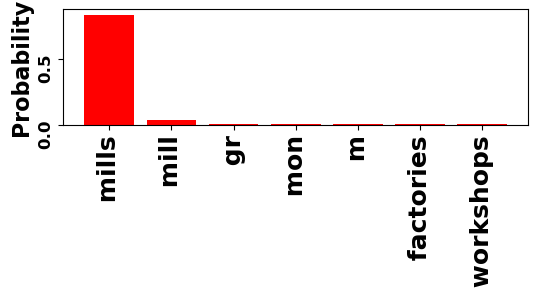

In [24]:
import torch
k = 7
logit_vector = logits[loss_position].detach()             

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.5), dpi=100)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens, color='red')
plt.xticks(rotation=90, fontweight='bold', fontsize=18)
# plt.xlabel('Token',rotation=180, fontweight='bold', fontsize=12)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

# plt.title(f'Top {k} Tokens in Softmax of Logits')
plt.show()

### Visualize attribution graph

In [25]:
### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors


log_color = 0

cmap = plt.get_cmap('Blues')

optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]

tick_label_text = optimized_tokens.copy()
            

if len(grads.shape) == 2:
    grad_magnitude = grads.norm(dim=-1).squeeze()  # shape [seq_len]
else:
    grad_magnitude = grads

grad_magnitude[grad_idx.index(loss_position+1)] = max(grad_magnitude[:grad_idx.index(loss_position+1)])

# Normalize grad_magnitude for color mapping
log_norm = Log_Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())
norm = Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())

if hidden_norm_as_loss:
    tick_label_text[grad_idx.index(loss_position+1)] = "&lt;predicted distribution&gt;"


bar_idx = grad_idx.index(loss_position+1)

if log_color:
    colors = cmap(log_norm(grad_magnitude.cpu().numpy()))
else:
    colors = cmap(norm(grad_magnitude.cpu().numpy()))

# Build HTML with colored boxes around each word, using bold font
def rgba_to_css(rgba):
    """Convert matplotlib RGBA to CSS rgba string"""
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

def get_text_color(bg_rgba):
    """Return white or black text based on background luminance"""
    luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
    return "white" if luminance < 0.5 else "black"

html_parts = []
for i, (token, color) in enumerate(zip(tick_label_text, colors)):
    bg_color = rgba_to_css(color)
    text_color = get_text_color(color)
    
    # Special styling for target token
    if i == bar_idx:
        # bg_color = "black"
        bg_color = "red"
        text_color = "white"
    
    # Clean up token display (remove leading space for display but keep for meaning)
    display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
    
    html_parts.append(
        f'<span style="'
        f'background-color: {bg_color}; '
        f'color: {text_color}; '
        f'padding: 0px 9px; '
        f'margin: 2px; '
        f'border-radius: 8px; '
        f'font-family: monospace; '
        f'font-size: 16px; '
        f'display: inline-block; '
        f'font-weight: bold;'   # <-- bold font here
        f'">{display_token}</span>'
    )

# === OPTION A: HTML display with fixed width ===
html_str = f'''
<div style="
    background: white; 
    padding: 20px; 
    border-radius: 8px; 
    line-height: 2.2;
    width: 550px;
    # width: 1100px;
">
    {"".join(html_parts)}
</div>
'''
display(HTML(html_str))


In [ ]:
### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors

log_color = 1


# cmap = plt.get_cmap('coolwarm')
# cmap = plt.get_cmap('viridis')
# cmap = plt.get_cmap('Greens')
cmap = plt.get_cmap('Blues')


# Normalize grad_magnitude for color mapping
log_norm = Log_Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())
norm = Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())

# # if hidden_norm_as_loss:
# if False:
#     tick_label_text[grad_idx.index(loss_position+1)] = "||vec||²"
# else:
#     tick_label_text[grad_idx.index(loss_position+1)] = "[target]"
#     # pass

bar_idx = grad_idx.index(loss_position+1)

if log_color:
    colors = cmap(log_norm(grad_magnitude.cpu().numpy()))
else:
    colors = cmap(norm(grad_magnitude.cpu().numpy()))

# Build HTML with colored boxes around each word, using bold font
def rgba_to_css(rgba):
    """Convert matplotlib RGBA to CSS rgba string"""
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

def get_text_color(bg_rgba):
    """Return white or black text based on background luminance"""
    luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
    return "white" if luminance < 0.5 else "black"

html_parts = []
for i, (token, color) in enumerate(zip(tick_label_text, colors)):
    bg_color = rgba_to_css(color)
    text_color = get_text_color(color)
    
    # Special styling for target token
    if i == bar_idx:
        # bg_color = "black"
        bg_color = "red"
        text_color = "white"
    
    # Clean up token display (remove leading space for display but keep for meaning)
    # display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
    # Show dot for tokens that are purely whitespace, but do not remove leading space otherwise
    # display_token = "1"+token 
    display_token = token 
    # print(display_token)
    
    html_parts.append(
        f'<span style="'
        f'background-color: {bg_color}; '
        f'color: {text_color}; '
        # f'padding: 0px 9px; '
        f'padding: 0px 0px; '
        # f'margin: 2px; '
        f'margin: 0px; '
        # f'border-radius: 8px; '
        f'border-radius: 0px; '
        f'font-family: monospace; '
        f'font-size: 16px; '
        f'display: inline-block; '
        f'font-weight: bold;'   # <-- bold font here
        # f'">{display_token}</span>'
        # To prevent collapsing of white spaces when displaying the token—including leading spaces—we can use CSS 'white-space: pre' so all spaces are rendered as-is.
        # This ensures that tokens like ' am' keep their leading space in the browser.
        f'white-space: pre;">{display_token}</span>'
    )

# === OPTION A: HTML display with fixed width ===
html_str = f'''
<div style="
    background: white; 
    padding: 20px; 
    border-radius: 8px; 
    line-height: 2.2;
    width: 550px;
    # width: 1100px;
">
    {"".join(html_parts)}
</div>
'''
display(HTML(html_str))




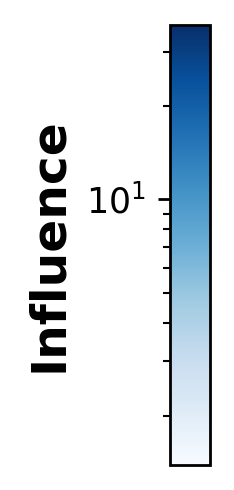

In [27]:
# Plot a vertical color bar below the tokens, matching the color mapping
import matplotlib as mpl

# Adjust the figure size to better fit the colorbar and avoid cutoff
fig_bar, ax_bar = plt.subplots(figsize=(0.4, 2.2), dpi=250)
fig_bar.subplots_adjust(left=0.3, right=0.7, bottom=0.1, top=0.9)

cbar = mpl.colorbar.ColorbarBase(
    ax_bar,
    cmap=cmap,
    norm=log_norm if log_color else norm,
    orientation='vertical'
)
cbar.set_label('Influence', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=10)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
plt.show()
